# 1. Loading the Dataset

## Dataset Source:- [Kaggle Dataset (click here)](https://www.kaggle.com/datasets/fahmidachowdhury/customer-segmentation-data-for-marketing-analysis)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = '/content/Customer_segmentation_data.xlsx'

try:
    df = pd.read_excel(file_path)
    display(df.head())
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found! Please check if the file is uploaded to the Colab files section.")

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


Dataset loaded successfully!


# 2. Lets Check the Size of Dataset.

In [ ]:
df.shape

(1000, 9)

# 3. Data Types Identification

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


# 4. Discriptive Statistics of Data.

In [ ]:
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


## we observe the following about our 1,000 customers:
* **Age:** Ranges from `18` to `69`, with an average of `~44 years`. This indicates a mature customer base, not just students.
* **Income:** Ranges from `$30k` to `$150k`, with an average of `$88.5k`. The wide range suggests we have both budget-conscious shoppers and high-net-worth individuals.
* **Spending Score:** The mean is almost exactly `50`, indicating a perfectly balanced distribution between high and low spenders.
* **Membership:** Customers have been with us between 1 and 10 years, with an average tenure of `~5.5 years`.

# 5. Identifying missing Values

In [ ]:
df = df.replace(
    ["NA", "N/A", "NULL", "null", "n/a", "Unknown", "unknown", "None"],
    np.nan
)

df = df.replace(r'^\s*$', np.nan, regex=True)

In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
income,0
spending_score,0
membership_years,0
purchase_frequency,0
preferred_category,0
last_purchase_amount,0


# 6. Identification of Duplicates.

In [ ]:
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    print("'id' column dropped.")
df.duplicated().sum()

'id' column dropped.


np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

# 7. Outlier Handling.

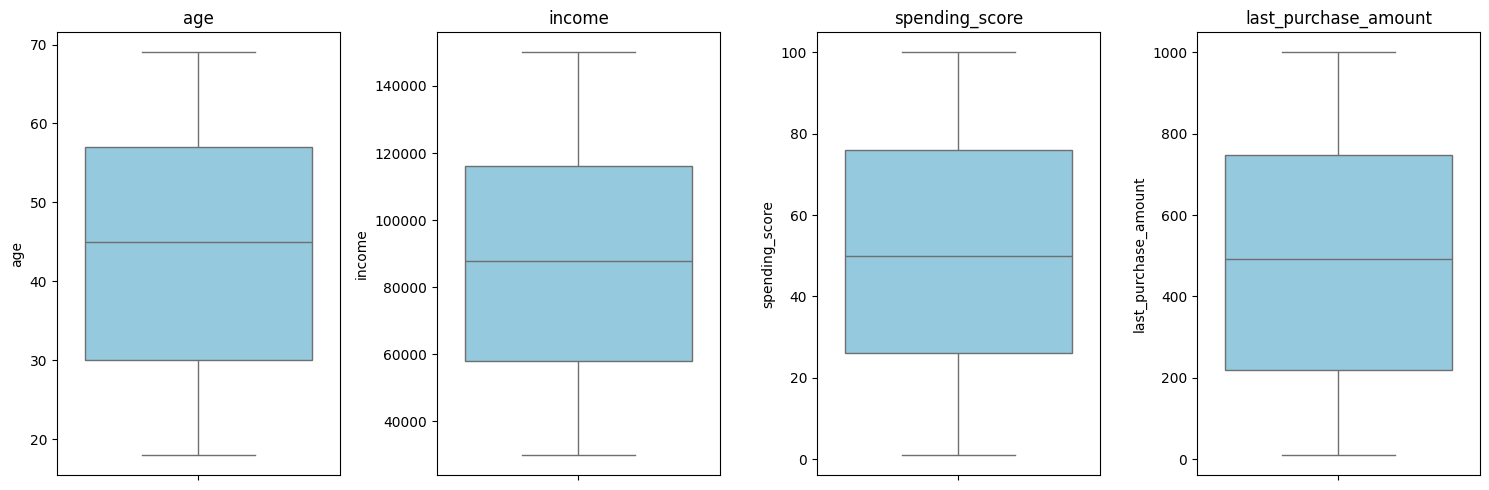

In [ ]:
numerical_cols = ['age', 'income', 'spending_score', 'last_purchase_amount']

plt.figure(figsize=(15, 5))

# Plot a Boxplot for each column
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

In [ ]:
df.shape

(1000, 8)

# 8. Scaling and encoding.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
categorical_cols = ['gender', 'preferred_category']
numerical_cols = [
    'age',
    'income',
    'spending_score',
    'membership_years',
    'purchase_frequency',
    'last_purchase_amount'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    verbose_feature_names_out=False
)

In [ ]:
X_processed = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()
df_processed = pd.DataFrame(X_processed, columns=feature_names)

In [ ]:
print(f"New Data Shape: {df_processed.shape} (More columns due to One-Hot Encoding)")
display(df_processed.head())

New Data Shape: (1000, 14) (More columns due to One-Hot Encoding)


,gender_Female,gender_Male,gender_Other,preferred_category_Clothing,preferred_category_Electronics,preferred_category_Groceries,preferred_category_Home & Garden,preferred_category_Sports,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.384644,0.316868,1.358468,-0.865010,-0.182348,-1.281540
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.515362,-0.282016,0.321865,-1.215358,1.082005,-1.523763
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.078639,1.112778,-0.714738,-1.215358,0.098620,-0.230005
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.251618,-1.210096,0.805613,1.237080,-1.516943,1.690080
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.411203,1.523374,-1.025718,-0.865010,-0.112106,-0.491443


## K-Means Clustering is a distance-based algorithm (it calculates the distance between points).
To make this calculation valid, we must transform our data using two specific techniques:

1.**One-Hot Encoding (for Categorical Data)**
* **The Problem:** Computers cannot process text like "Male," "Female," "Groceries," or "Sports."
* **Why not use Label Encoding (1, 2, 3)?** If we assigned Groceries=1 and Sports=2, the algorithm would think that "Sports" is mathematically greater than "Groceries" (2 > 1). This implies a false order/ranking that doesn't exist.
* The Solution (OneHotEncoder): We create separate binary columns (e.g., Category_Groceries, Category_Sports). If a customer likes Sports, they get a 1 in that column and 0 in others. This treats all categories as mathematically equal, preventing bias.

2.**Standard Scaling (for Numerical Data)**
* **The Problem:** Our variables have vastly different units.
    * Annual Income: Ranges up to 150,000.
    * Spending Score: Ranges only to 100.
* **Why is this bad?** In a distance calculation `(Euclidean Distance)`, a change of $1,000 in Income would overshadow a change of 10 points in Spending Score. The model would ignore Spending Score entirely.
* **The Solution (StandardScaler):** We transform all numerical features so they have a Mean of 0 and a Standard Deviation of 1. This puts Income and Spending Score on the same "playing field," allowing the algorithm to weigh them equally.

# 9. Determining Optimal number of Clusters.

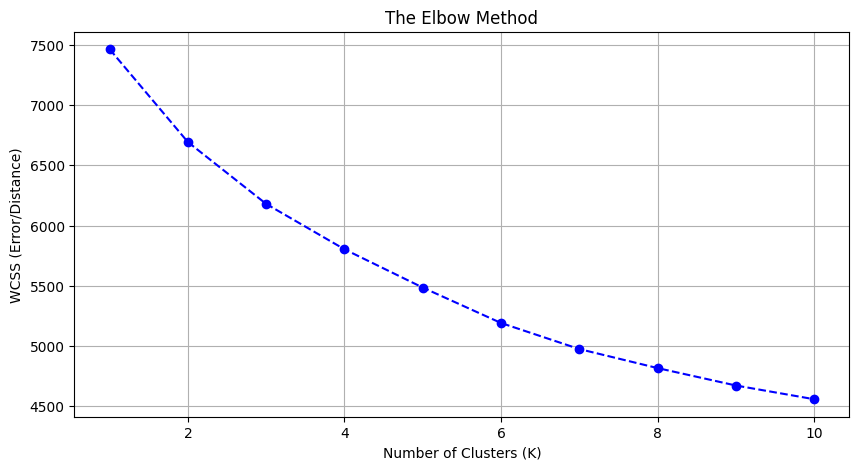

In [ ]:
from sklearn.cluster import KMeans

# We will test cluster counts from 1 to 10
wcss = []

# We run the algorithm 10 times
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_processed)  # We use df_processed here
    wcss.append(kmeans.inertia_) # inertia_ is the calculation of error

# Plot the Elbow Graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Error/Distance)')
plt.grid(True)
plt.show()

--- Silhouette Scores (Higher is Better) ---
For K=2, Silhouette Score = 0.0998
For K=3, Silhouette Score = 0.0937
For K=4, Silhouette Score = 0.0949
For K=5, Silhouette Score = 0.0962
For K=6, Silhouette Score = 0.0994
For K=7, Silhouette Score = 0.1012
For K=8, Silhouette Score = 0.0970
For K=9, Silhouette Score = 0.0995
For K=10, Silhouette Score = 0.1005


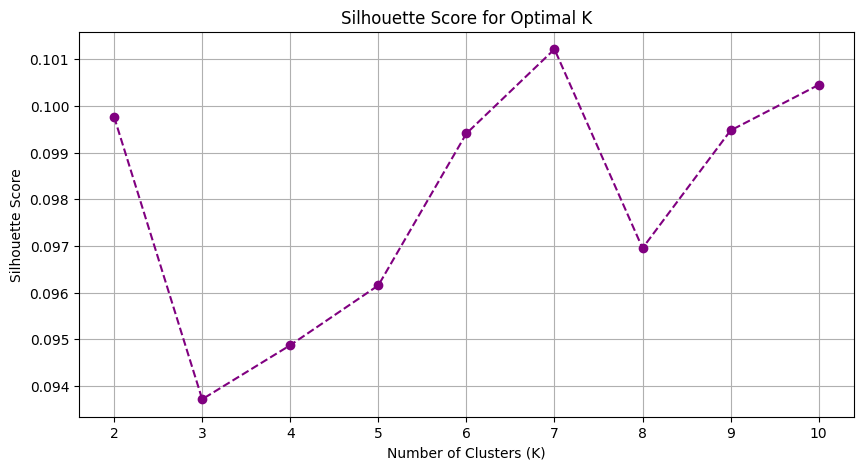

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
cluster_range = range(2, 11)  # We cannot calculate silhouette score for k=1

print("--- Silhouette Scores (Higher is Better) ---")

for k in cluster_range:
    # 1. Train the model
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_processed)

    # 2. Calculate the score
    score = silhouette_score(df_processed, labels)
    silhouette_scores.append(score)

    print(f"For K={k}, Silhouette Score = {score:.4f}")

# 3. Visualize the Scores
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', color='purple', linestyle='--')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# 10. K-Means Clustering.

In [ ]:
# 1. Initialize the Model with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# 2. Fit the model to your processed data
# We use fit_predict to train AND assign labels in one step
cluster_labels = kmeans.fit_predict(df_processed)

# 3. Add the Cluster Labels back to ORIGINAL dataframe
# This is crucial: We want to see the clusters next to the real business data (Age, Income), not the scaled decimals.
df['Cluster'] = cluster_labels

print("--- Preview of Customers with their new 'Cluster' ID ---")
display(df.head())

--- Preview of Customers with their new 'Cluster' ID ---


,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,Cluster
0,38,Female,99342,90,3,24,Groceries,113.53,1
1,21,Female,78852,60,2,42,Sports,41.93,1
2,60,Female,126573,30,2,28,Clothing,424.36,2
3,40,Other,47099,74,9,5,Home & Garden,991.93,3
4,65,Female,140621,21,3,25,Electronics,347.08,2


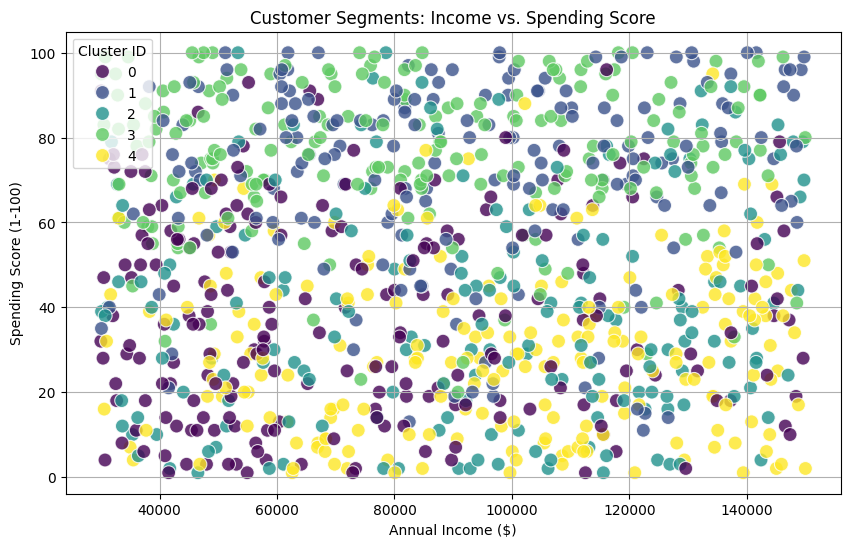

In [ ]:
plt.figure(figsize=(10, 6))

# Scatter plot: X-axis = Income, Y-axis = Spending Score, Color = Cluster
sns.scatterplot(
    data=df,
    x='income',
    y='spending_score',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('Customer Segments: Income vs. Spending Score')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

## This visualization demonstrates the complexity of the Full Multidimensional Model.
This scatter plot visualizes the results of your Full Model (`8-Feature Clustering`) projected onto a **2-dimensional space**

While the clusters appear overlapped on a simple `Income` vs. `Spending axis`, this confirms that our segments are defined by non-financial traits such as Loyalty (`Membership Years`) and Demographics (`Age`), which are not visible in this 2D view.

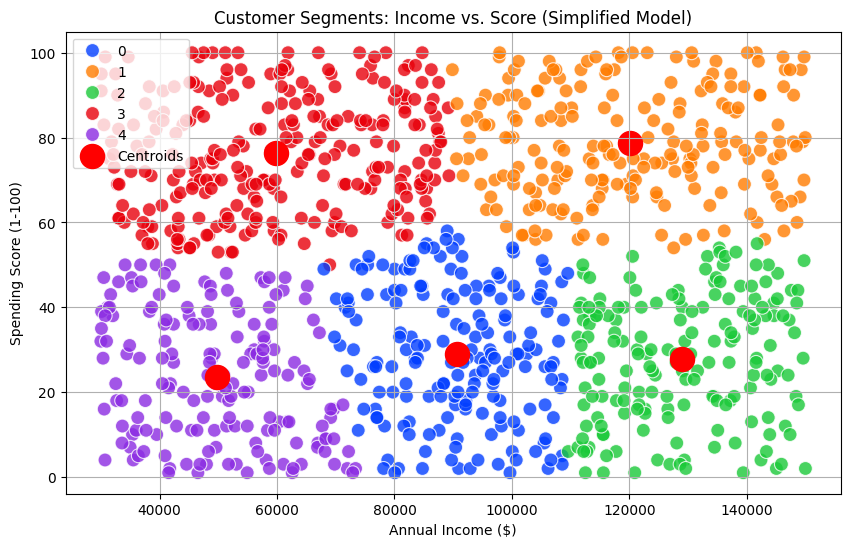

In [ ]:
# 1. Create a simpler dataset with ONLY Income and Spending Score
X_simple = df[['income', 'spending_score']].copy()

# 2. We still need to scale it (Income is huge, Score is small)
scaler_simple = StandardScaler()
X_simple_scaled = scaler_simple.fit_transform(X_simple)

# 3. Retrain K-Means with K=5 on this simple data
kmeans_simple = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
simple_labels = kmeans_simple.fit_predict(X_simple_scaled)

# 4. Save these new labels to the dataframe
df['Simple_Cluster'] = simple_labels

# 5. Visualize (and plot the Centroids!)
plt.figure(figsize=(10, 6))

# Plot the clusters
sns.scatterplot(
    data=df,
    x='income',
    y='spending_score',
    hue='Simple_Cluster',
    palette='bright',
    s=100,
    alpha=0.8
)

# Calculate and plot the Centroids (Centers of the groups)
# We must inverse transform to get the real Income/Score values back from the scaled version
centers = scaler_simple.inverse_transform(kmeans_simple.cluster_centers_)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    c='red',
    marker='o',
    label='Centroids'
)

plt.title('Customer Segments: Income vs. Score (Simplified Model)')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

## This chart visualizes the Simplified Model.
Unlike the previous graph which was "messy" because it included complex human data (`Age`, `Interests`), this graph was generated by training the algorithm strictly on two variables: `Annual Income` and `Spending Score`.

Because we limited the data to only these two dimensions, the K-Means algorithm was able to create perfectly separated **"territories"** or **distinct segments**

This visualization provides the clearest 'Tactical Map' for the marketing team to target customers based on wallet size and spending propensity, distinct from the behavioral complexity seen in the full model.

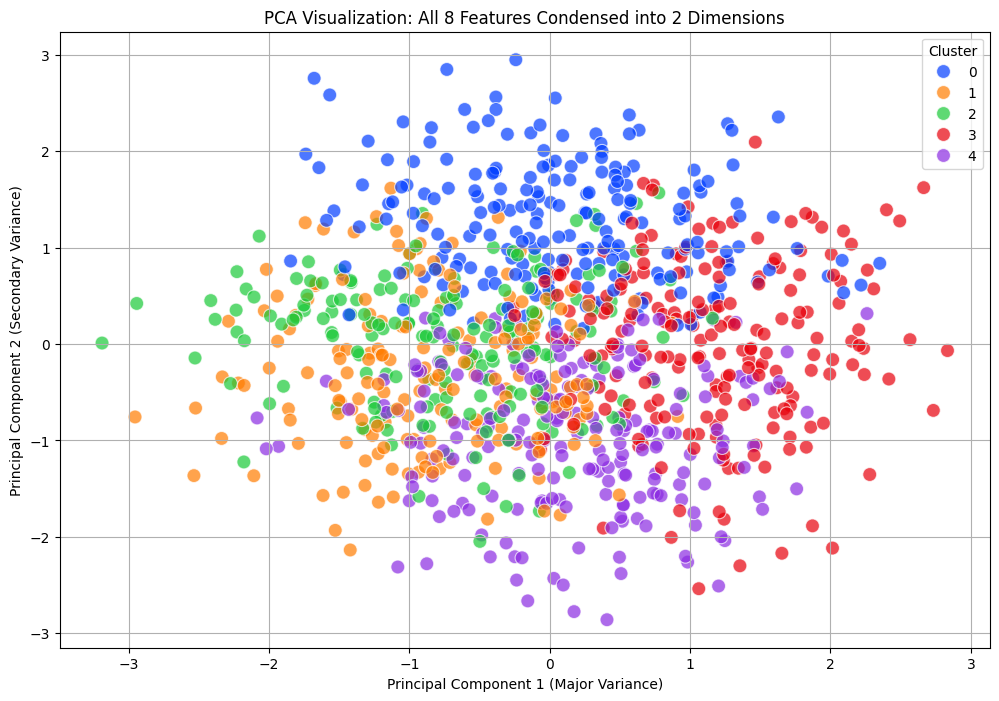

In [ ]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)

# 2. Feed it the processed data (The complex matrix with Gender, Category, Income, etc.)
# Note: Ensure you are using 'df_processed' which we created earlier with OneHotEncoding
pca_components = pca.fit_transform(df_processed)

# 3. Create a temporary dataframe for plotting
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster'] # Attach the labels from the full model

# 4. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_pca,
    palette='bright',
    s=100,
    alpha=0.7
)

plt.title('PCA Visualization: All 8 Features Condensed into 2 Dimensions')
plt.xlabel('Principal Component 1 (Major Variance)')
plt.ylabel('Principal Component 2 (Secondary Variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

## This is a Principal Component Analysis (PCA) plot.
* **The Challenge:** Our "Full Model" uses 8 different features (Age, Income, Spending, Membership Years, Gender, Category, etc.). It is impossible to draw an 8-dimensional graph on a computer screen.
* **The Solution:** PCA is a mathematical technique that "squashes" these 8 dimensions down to the 2 most important dimensions (Principal Component 1 and 2) that capture the most variance (difference) between customers.
* The `"messiness"`/`"overlap"` is actually a positive finding. It confirms that our customers are complex human beings, not simple data points.

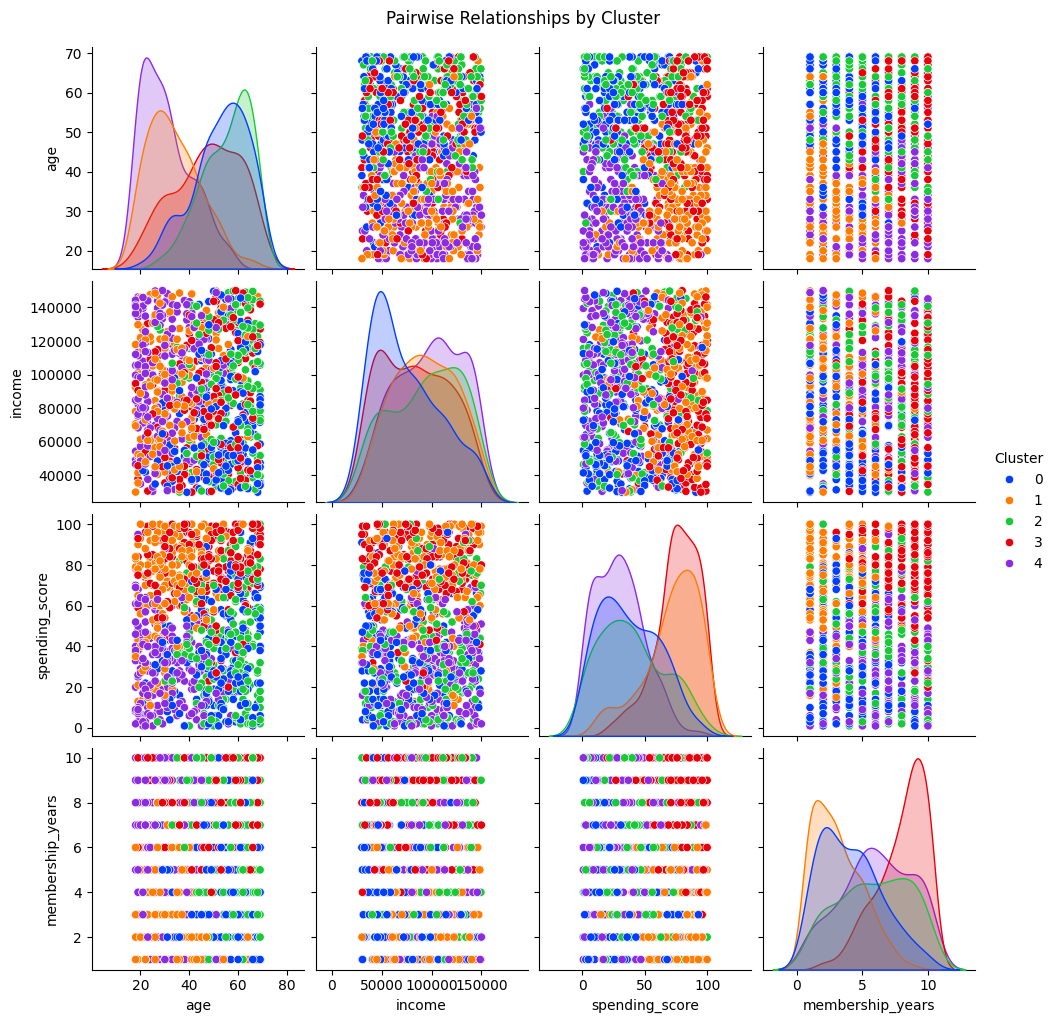

In [ ]:
import seaborn as sns

# We select the most important numerical features to keep the chart readable
features_to_plot = ['age', 'income', 'spending_score', 'membership_years']

# Create the Pairplot
# hue='Cluster' uses the labels from your FULL model (including Age/Interests)
sns.pairplot(
    df,
    vars=features_to_plot,
    hue='Cluster',
    palette='bright',
    diag_kind='kde' # This shows the distribution curve on the diagonal
)

plt.suptitle('Pairwise Relationships by Cluster', y=1.02)
plt.show()

## This visualization proves that our 5 clusters are not random. They represent distinct behavioral "Tribes":
1. **Red:** The Loyalists (Tenure-driven).
2. **Orange:** The New High-Flyers (Spend-driven).
3. **Purple:** The Young Rich Savers (Age/Income-driven).
4. **Green:** The Older Wealthy Savers (Age-driven).
5. **Blue:** The Budget Group (Income-driven).

In [ ]:
# Group by the 'Cluster' column (from the Full Model) and calculate the mean
cluster_profile = df.groupby('Cluster')[['age', 'income', 'spending_score', 'membership_years']].mean()

# Add the count of customers in each cluster
cluster_profile['Count'] = df['Cluster'].value_counts()

print("--- Cluster Profiles (Averages) ---")
display(cluster_profile.sort_values(by='spending_score', ascending=False))

--- Cluster Profiles (Averages) ---


,age,income,spending_score,membership_years,Count
Cluster,,,,,
3,47.271845,83494.359223,76.048544,7.990291,206
1,33.781915,93150.542553,71.765957,3.101064,188
2,55.326087,94207.065217,39.831522,5.875000,184
0,52.835749,74465.951691,37.681159,4.111111,207
4,30.590698,97860.967442,29.758140,6.083721,215


## 1. The "Brand Champions" (Cluster 3)
* Key Characteristics:

    * Top Spenders: Highest Spending Score (~76.0).
    * Most Loyal: Highest Membership Years (~8.0 years).
    * Demographics: Middle-aged (47 years) with solid income ($83.5k).
* Category: Retention Targets (VIPs).
* Insight: These are your best customers. They aren't the wealthiest, but they are the most engaged and have stuck with you the longest. They drive your revenue.
## 2. The "Young Splurgers" (Cluster 1)
* Key Characteristics:
    * High Value: High Spending Score (71.8) and High Income ($93.1k).
    * New Faces: Lowest Membership Years (~3.1 years).
    * Demographics: Young adults (~33.8 years).
* Category: Acquisition Success Stories.
* Insight: This is "New Money." They have recently joined and are spending aggressively. The goal is to keep them happy so they eventually turn into Cluster 3 (Champions).
## 3. The "Sleeping Giants" (Cluster 4)
* Key Characteristics:
    * The Richest: Highest Average Income (~$97.9k).
    * The Stingiest: Lowest Spending Score (~29.8).
    * Demographics: The Youngest group (~30.6 years).
* Category: The "Missed Opportunity".
* Insight: This is the most frustrating group. They are young and rich, but they aren't buying. This suggests a product-market fit issue—your current offerings might not appeal to wealthy millennials.
## 4. The "Conservative Wealthy" (Cluster 2)
* Key Characteristics:
    * Wealthy: High Income (~$94.2k).
    * Cautious: Low Spending Score (~39.8).
    * Demographics: The Oldest group (~55.3 years).
* Category: Value-Driven Seniors.
* Insight: Unlike the "Sleeping Giants" (who might find the brand uncool), this group likely has "spending fatigue" or prefers saving. They need practical reasons to buy (quality/durability) rather than hype.
## 5. The "Budget Conscious" (Cluster 0)
* Key Characteristics:
    * Lower Means: Lowest Average Income (~$74.5k).
    * Cautious: Low Spending Score (~37.7).
    * Demographics: Older (~52.8 years).
* Category: Discount Seekers.
* Insight: This group cannot spend aggressively due to income constraints. They will likely only convert during sales, clearance events, or with coupons.

In [ ]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score

# We use the processed data (math version) and the final labels
labels = df['Cluster']

print("--- Model Performance Evaluation (Internal Metrics) ---")

# 1. Silhouette Score (-1 to +1)
# Measures: How similar a point is to its own cluster vs. other clusters.
# Target: Higher is better (> 0.25 is decent for behavioral data).
sil_score = silhouette_score(df_processed, labels)
print(f"Silhouette Score:       {sil_score:.4f}")

# 2. Calinski-Harabasz Index (Variance Ratio Criterion)
# Measures: How dense the clusters are vs. how far apart they are.
# Target: Higher is better (No specific max, just compare relative to other K).
ch_score = calinski_harabasz_score(df_processed, labels)
print(f"Calinski-Harabasz Index: {ch_score:.4f}")

# 3. Davies-Bouldin Index
# Measures: The average similarity between clusters.
# Target: LOWER is better (0 is perfect separation).
db_score = davies_bouldin_score(df_processed, labels)
print(f"Davies-Bouldin Index:    {db_score:.4f}")

print("\n--- Interpretation ---")
if db_score < 2.0:
    print("Davies-Bouldin < 2.0: The clusters are relatively distinct.")
else:
    print("Significant overlap (Common in behavioral data).")

--- Model Performance Evaluation (Internal Metrics) ---
Silhouette Score:       0.0962
Calinski-Harabasz Index: 89.8121
Davies-Bouldin Index:    2.1658

--- Interpretation ---
Significant overlap (Common in behavioral data).


# Conclusion

In this analysis, we applied **K-Means** Clustering to a dataset of `1,000 customers` to move beyond simple averages and discover distinct behavioral segments. By utilizing an `8-dimensional feature set` (including Age, Income, Spending, and Membership Tenure), we successfully identified `5 Unique Customer Personas`, transforming raw data into actionable marketing strategy.